In [4]:
from xcube.core.store import new_data_store
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry

In [3]:
%load_ext autoreload
%autoreload 2

### Land Cover

In [6]:
cci_ds = new_data_store("cciodp")

In [7]:
cci_ds.list_data_ids()

['esacci.GHG.satellite-orbit-frequency.L2.CH4.TROPOMI.Sentinel-5P.WFMD.v1-8.201711-202406',
 'esacci.AEROSOL.5-days.L3C.AEX.GOMOS.Envisat.AERGOM.3-00.r1',
 'esacci.AEROSOL.climatology.L3.AAI.multi-sensor.multi-platform.MSAAI.1-7.r1',
 'esacci.AEROSOL.day.L3.AAI.multi-sensor.multi-platform.MSAAI.1-7.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.ADV.2-31.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.ORAC.04-01-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.ORAC.04-01_seg-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.SU.4-3.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.ADV.2-31.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.ORAC.04-01-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.ORAC.04-01_seg-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.SU.4-3.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.multi-sensor.multi-platform.AATSR-ENVISAT-ENS_DAILY.v2-6.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.multi-sensor.mult

In [9]:
cci_ds.describe_data("esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1")

In [10]:
cci_ds.get_open_data_params_schema("esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1")

In [11]:
bbox = [-31, 27, 40, 81]

In [12]:
time_range = ["2015-01-01", "2015-12-31"]

In [27]:
lc_cci = cci_ds.open_data(
    "esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1", 
    bbox=bbox, 
    time_range=time_range,
)

In [28]:
lc_cci

<xarray.Dataset> Size: 10GB
Dimensions:              (time: 1, lat: 19440, lon: 25560, bnds: 2)
Coordinates:
  * lat                  (lat) float32 78kB 81.0 81.0 80.99 ... 27.01 27.0 27.0
  * lon                  (lon) float32 102kB -31.0 -31.0 -30.99 ... 40.0 40.0
  * time                 (time) datetime64[ns] 8B 2015-07-02T12:00:00
    time_bnds            (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    change_count         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    crs                  float64 8B ...
    current_pixel_state  (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform...
    date_created:            2025-08-04T14:52:55.159408
    processing_level:        L4
    time_coverage_start:     2015-01-01T00:00:00
    time_coverage_end:       2016-01-01T00:00:00
    time_coverage_duration:  P365DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

CPU times: user 11.5 s, sys: 3.95 s, total: 15.4 s
Wall time: 2min 18s


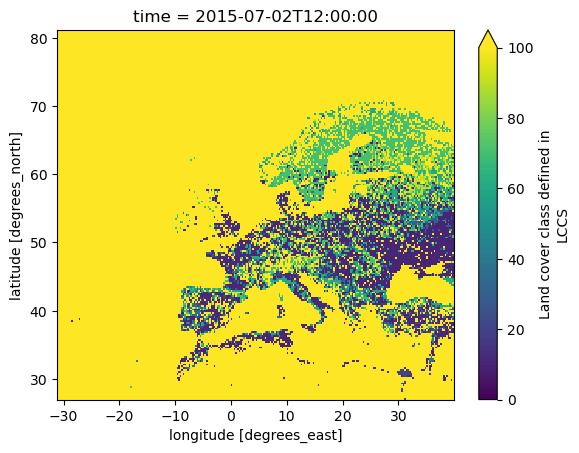

In [18]:
%%time
downsampled_cube = lc_cci.lccs_class.isel(
    lat=slice(None, None, 100),
    lon=slice(None, None, 100),
)
downsampled_cube.plot(vmin=0, vmax=100)

## The cells below use LC from S3 data cube prepared by BC (will be used later. Skip for now!)

In [2]:
store_lccs=new_data_store("s3", root="deep-esdl-public")
mlds_lc = store_lccs.open_data("LC-1x2025x2025-2.0.0.levels")
lc = mlds_lc.base_dataset

In [56]:
file_store = new_data_store("file", root="input_sources")

In [58]:
file_store.write_data(lc, "LC-1x2025x2025-2.0.0.zarr")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x70242bffb4d0>>
Traceback (most recent call last):
  File "/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x70242bffb4d0>>
Traceback (most recent call last):
  File "/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

KeyboardInterrupt: 

In [3]:
landcover = lc.sel(time="2020-01-01")
landcover

<xarray.Dataset> Size: 101GB
Dimensions:              (lat: 64800, lon: 129600, bounds: 2)
Coordinates:
  * lat                  (lat) float64 518kB 90.0 90.0 89.99 ... -90.0 -90.0
  * lon                  (lon) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0
    time                 datetime64[ns] 8B 2020-01-01
Dimensions without coordinates: bounds
Data variables:
    change_count         (lat, lon) uint8 8GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    crs                  int32 4B ...
    current_pixel_state  (lat, lon) float32 34GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    lat_bounds           (lat, bounds) float64 1MB dask.array<chunksize=(2025, 2), meta=np.ndarray>
    lccs_class           (lat, lon) uint8 8GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    lon_bounds           (lon, bounds) float64 2MB dask.array<chunksize=(2025, 2), meta=np.ndarray>
    observation_count    (lat, lon) uint16 17GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    processed_flag       (lat, lon) float32 34GB dask.array<chunksize=(2025, 2025), meta=np.ndarray>
    time_bounds          (bounds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

In [4]:
lc_gm = GridMapping.from_dataset(landcover)
lc_gm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.002777775, 0.002777775)
* xy_bbox: (-180, -90, 180, 90)
* ij_bbox: (0, 0, 129600, 64800)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (129600, 64800)
* tile_size: (2025, 2025)

CPU times: user 12.8 s, sys: 1.65 s, total: 14.4 s
Wall time: 33.1 s


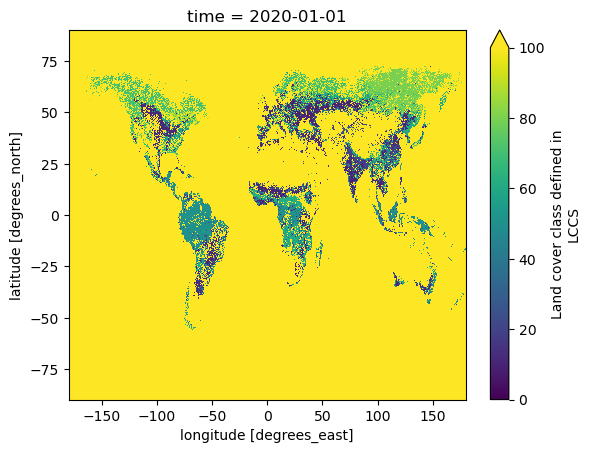

In [5]:
%%time
downsampled_cube = landcover.lccs_class.isel(
    lat=slice(None, None, 100),
    lon=slice(None, None, 100),
)
downsampled_cube.plot(vmin=0, vmax=100)

## Skipping ends here!

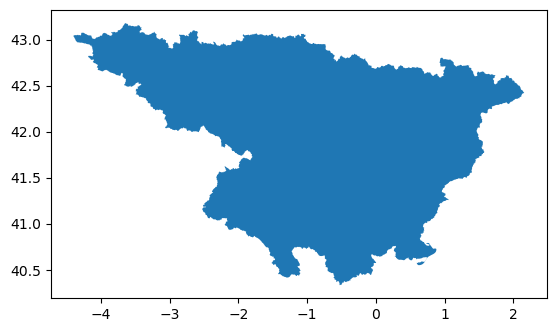

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()


In [20]:
print(gdf.crs) 

EPSG:4326


In [21]:
gdf.geometry

0    POLYGON ((-3.64513 43.17854, -3.64489 43.17853...
Name: geometry, dtype: geometry

In [29]:
masked_lc = mask_dataset_by_geometry(lc_cci, gdf.geometry[0])
masked_lc

<xarray.Dataset> Size: 68MB
Dimensions:              (lat: 1025, lon: 2363, time: 1, bnds: 2)
Coordinates:
  * lat                  (lat) float32 4kB 43.18 43.18 43.18 ... 40.34 40.34
  * lon                  (lon) float32 9kB -4.404 -4.401 -4.399 ... 2.154 2.157
  * time                 (time) datetime64[ns] 8B 2015-07-02T12:00:00
    time_bnds            (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    change_count         (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    crs                  (lat, lon) float64 19MB dask.array<chunksize=(1025, 1287), meta=np.ndarray>
    current_pixel_state  (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
Attributes: (12/19)
    Conventions:                CF-1.7
    title:                      esacci.LC.yr.L4.LCCS.multi-sensor.multi-platf...
    date_created:               2025-08-04T14:52:55.159408
    processing_level:           L4
    time_coverage_start:        2015-01-01T00:00:00
    time_coverage_end:          2016-01-01T00:00:00
    ...                         ...
    geospatial_lat_min:         40.33611106337891
    geospatial_lat_max:         43.18333626328125
    geospatial_lat_resolution:  0.002780925
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.405555248260498 40.33611106337891...
    date_modified:              2025-08-04T14:53:02.660173

In [30]:
lat_range = (float(masked_lc.lat.min()), float(masked_lc.lat.max()))
lon_range = (float(masked_lc.lon.min()), float(masked_lc.lon.max()))
lat_range, lon_range

((40.337501525878906, 43.18194580078125),
 (-4.4041666984558105, 2.156944513320923))

CPU times: user 2.17 s, sys: 242 ms, total: 2.41 s
Wall time: 5.81 s


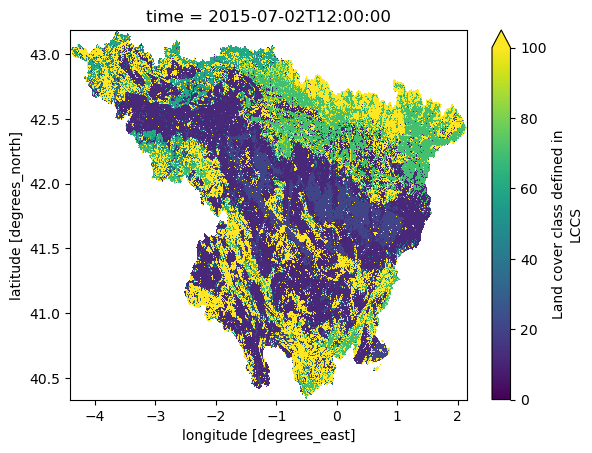

In [31]:
%%time
# downsampled_cube = masked_lc.lccs_class.isel(
#     lat=slice(None, None, 100),
#     lon=slice(None, None, 100),
# )
masked_lc.lccs_class.plot(vmin=0, vmax=100)

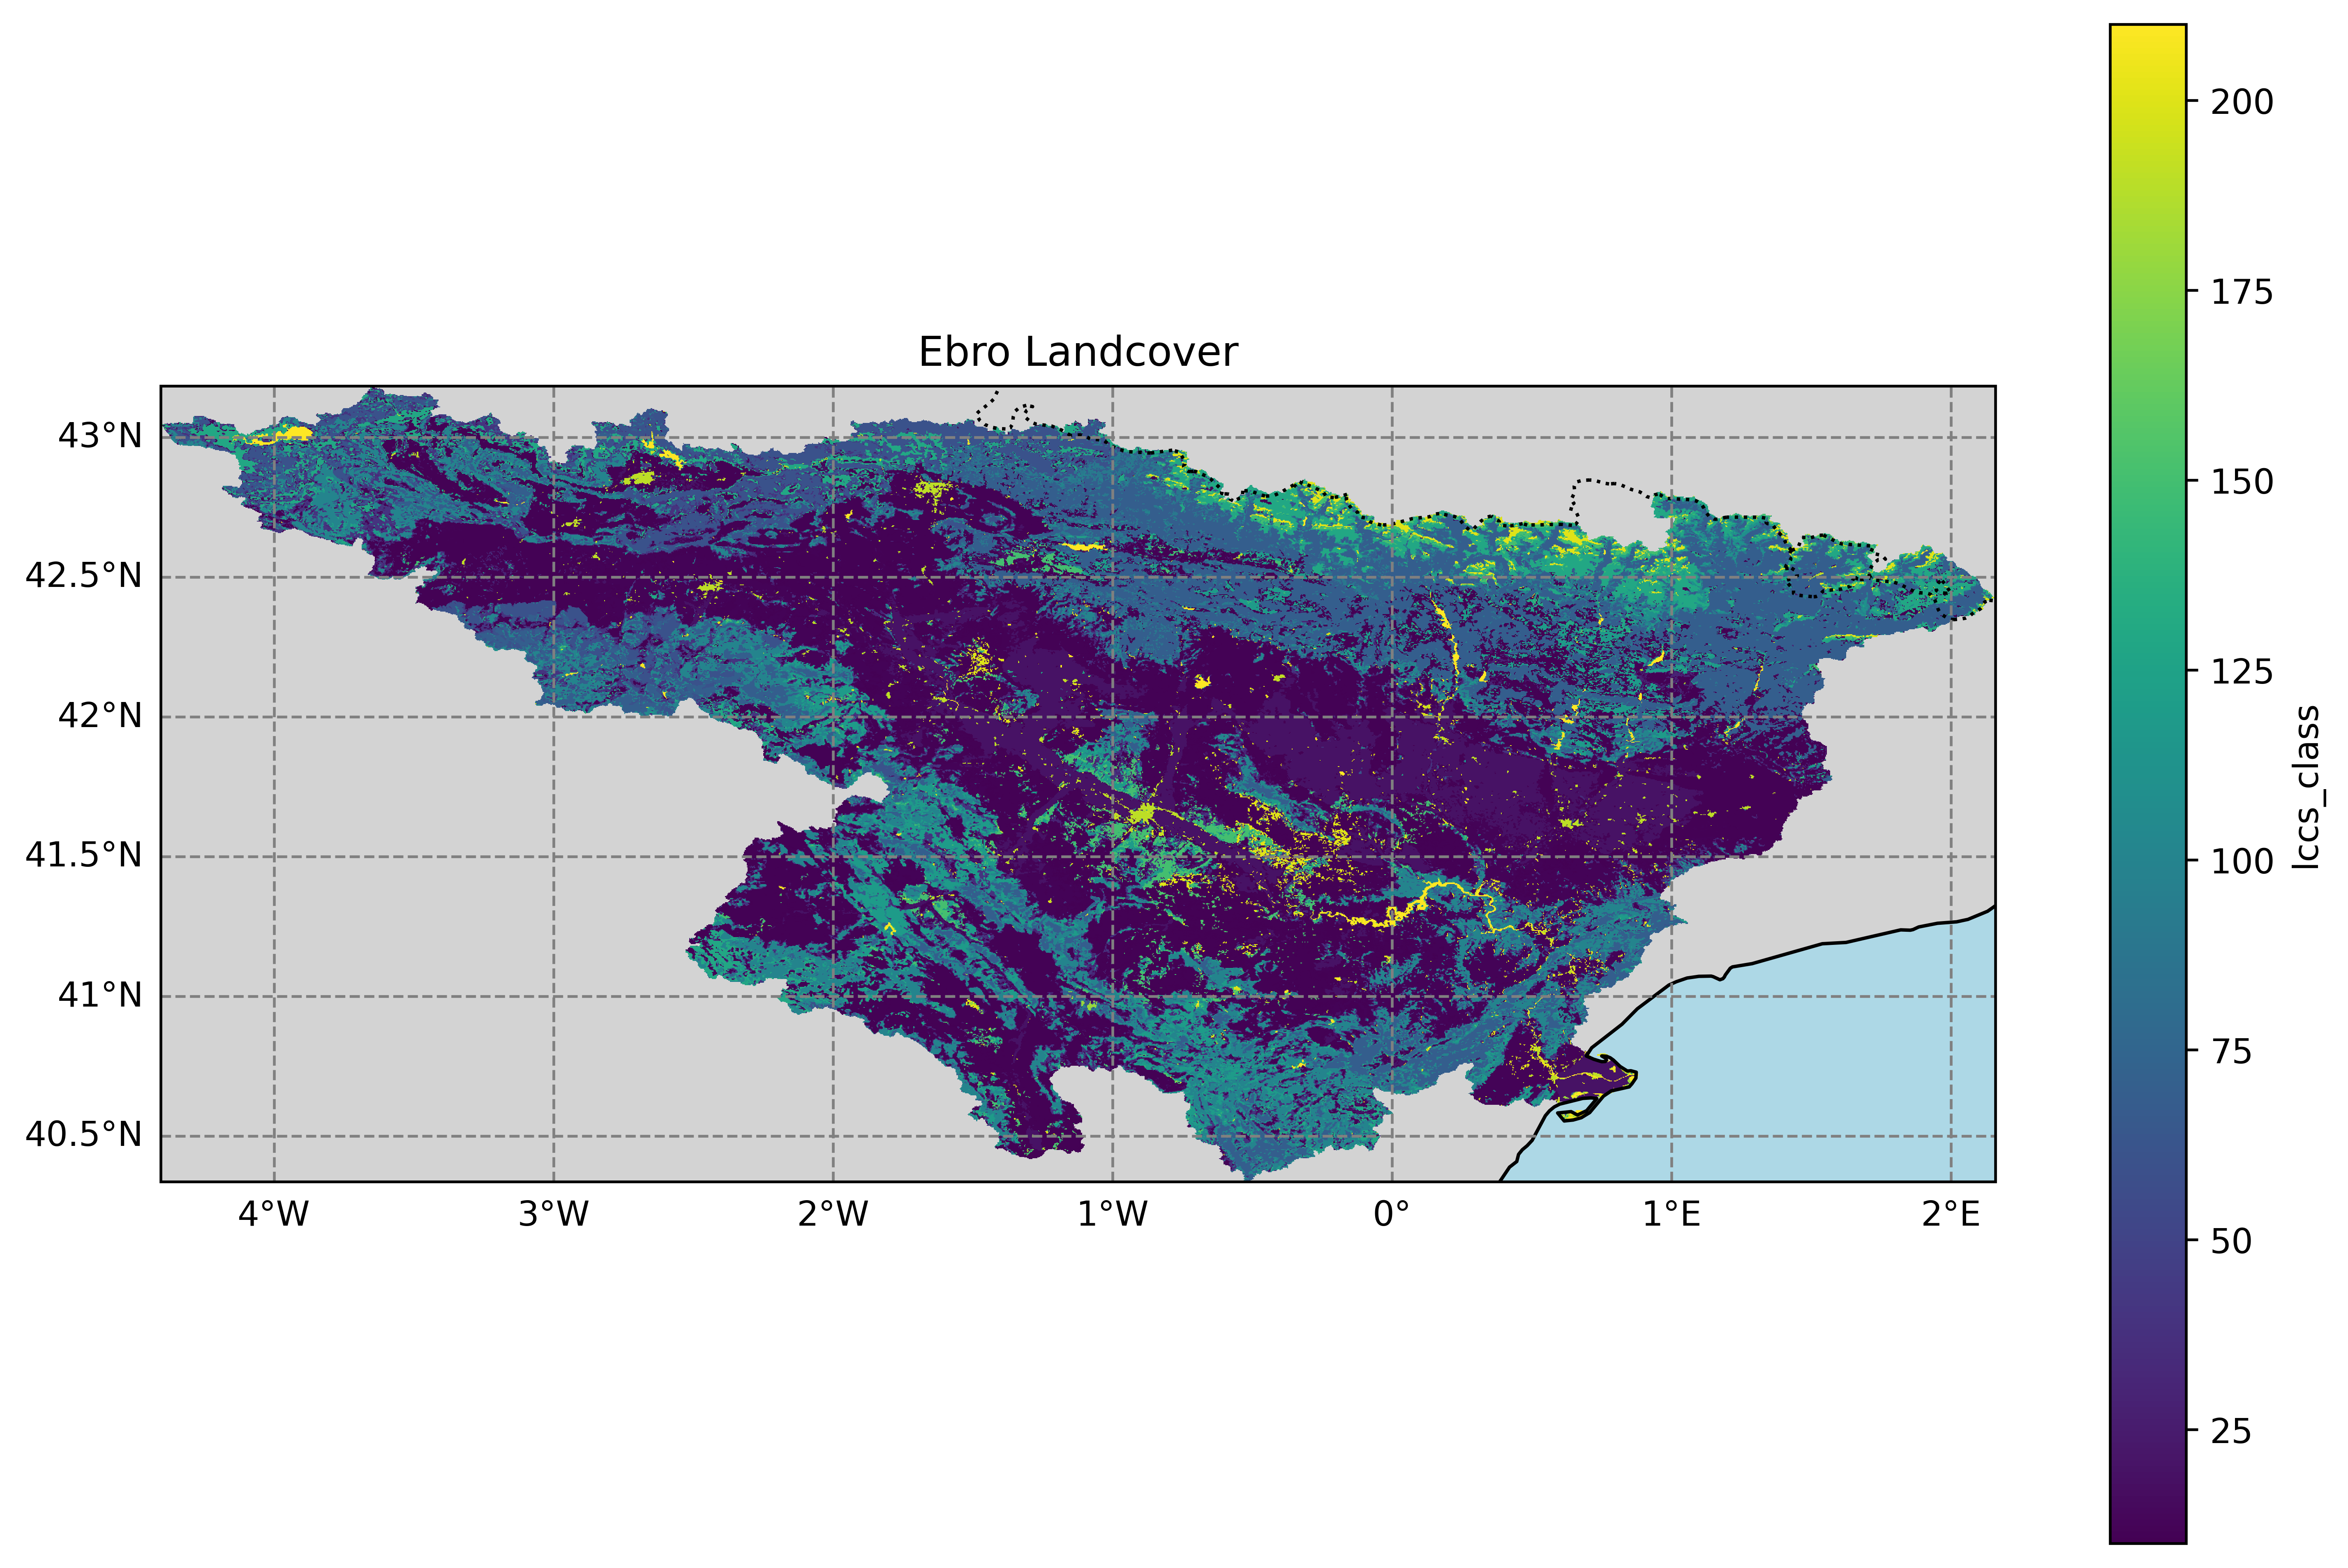

In [33]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = masked_lc["lccs_class"].isel(time=0)
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()


In [34]:
masked_lc

<xarray.Dataset> Size: 68MB
Dimensions:              (lat: 1025, lon: 2363, time: 1, bnds: 2)
Coordinates:
  * lat                  (lat) float32 4kB 43.18 43.18 43.18 ... 40.34 40.34
  * lon                  (lon) float32 9kB -4.404 -4.401 -4.399 ... 2.154 2.157
  * time                 (time) datetime64[ns] 8B 2015-07-02T12:00:00
    time_bnds            (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    change_count         (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    crs                  (lat, lon) float64 19MB dask.array<chunksize=(1025, 1287), meta=np.ndarray>
    current_pixel_state  (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 10MB dask.array<chunksize=(1, 1025, 1076), meta=np.ndarray>
Attributes: (12/19)
    Conventions:                CF-1.7
    title:                      esacci.LC.yr.L4.LCCS.multi-sensor.multi-platf...
    date_created:               2025-08-04T14:52:55.159408
    processing_level:           L4
    time_coverage_start:        2015-01-01T00:00:00
    time_coverage_end:          2016-01-01T00:00:00
    ...                         ...
    geospatial_lat_min:         40.33611106337891
    geospatial_lat_max:         43.18333626328125
    geospatial_lat_resolution:  0.002780925
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.405555248260498 40.33611106337891...
    date_modified:              2025-08-04T14:53:02.660173

In [35]:
keep_classes = [10, 11, 12, 20, 30]

In [36]:
filtered_lc = masked_lc.lccs_class.where(masked_lc["lccs_class"].isin(keep_classes))

In [37]:
filtered_lc

<xarray.DataArray 'lccs_class' (time: 1, lat: 1025, lon: 2363)> Size: 10MB
dask.array<where, shape=(1, 1025, 2363), dtype=float32, chunksize=(1, 1025, 1076), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 4kB 43.18 43.18 43.18 43.17 ... 40.34 40.34 40.34
  * lon      (lon) float32 9kB -4.404 -4.401 -4.399 -4.396 ... 2.151 2.154 2.157
  * time     (time) datetime64[ns] 8B 2015-07-02T12:00:00
Attributes: (12/16)
    long_name:            Land cover class defined in LCCS
    standard_name:        land_cover_lccs
    flag_values:          [0, 10, 11, 12, 20, 30, 40, 50, 60, 61, 62, 70, 71,...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    valid_min:            1
    valid_max:            220
    ...                   ...
    shape:                [1, 19440, 25560]
    chunk_sizes:          [1, 1944, 2130]
    file_chunk_sizes:     [1944, 2130]
    data_type:            uint8
    dimensions:           ['time', 'lat', 'lon']
    file_dimensions:      ['lat', 'lon']

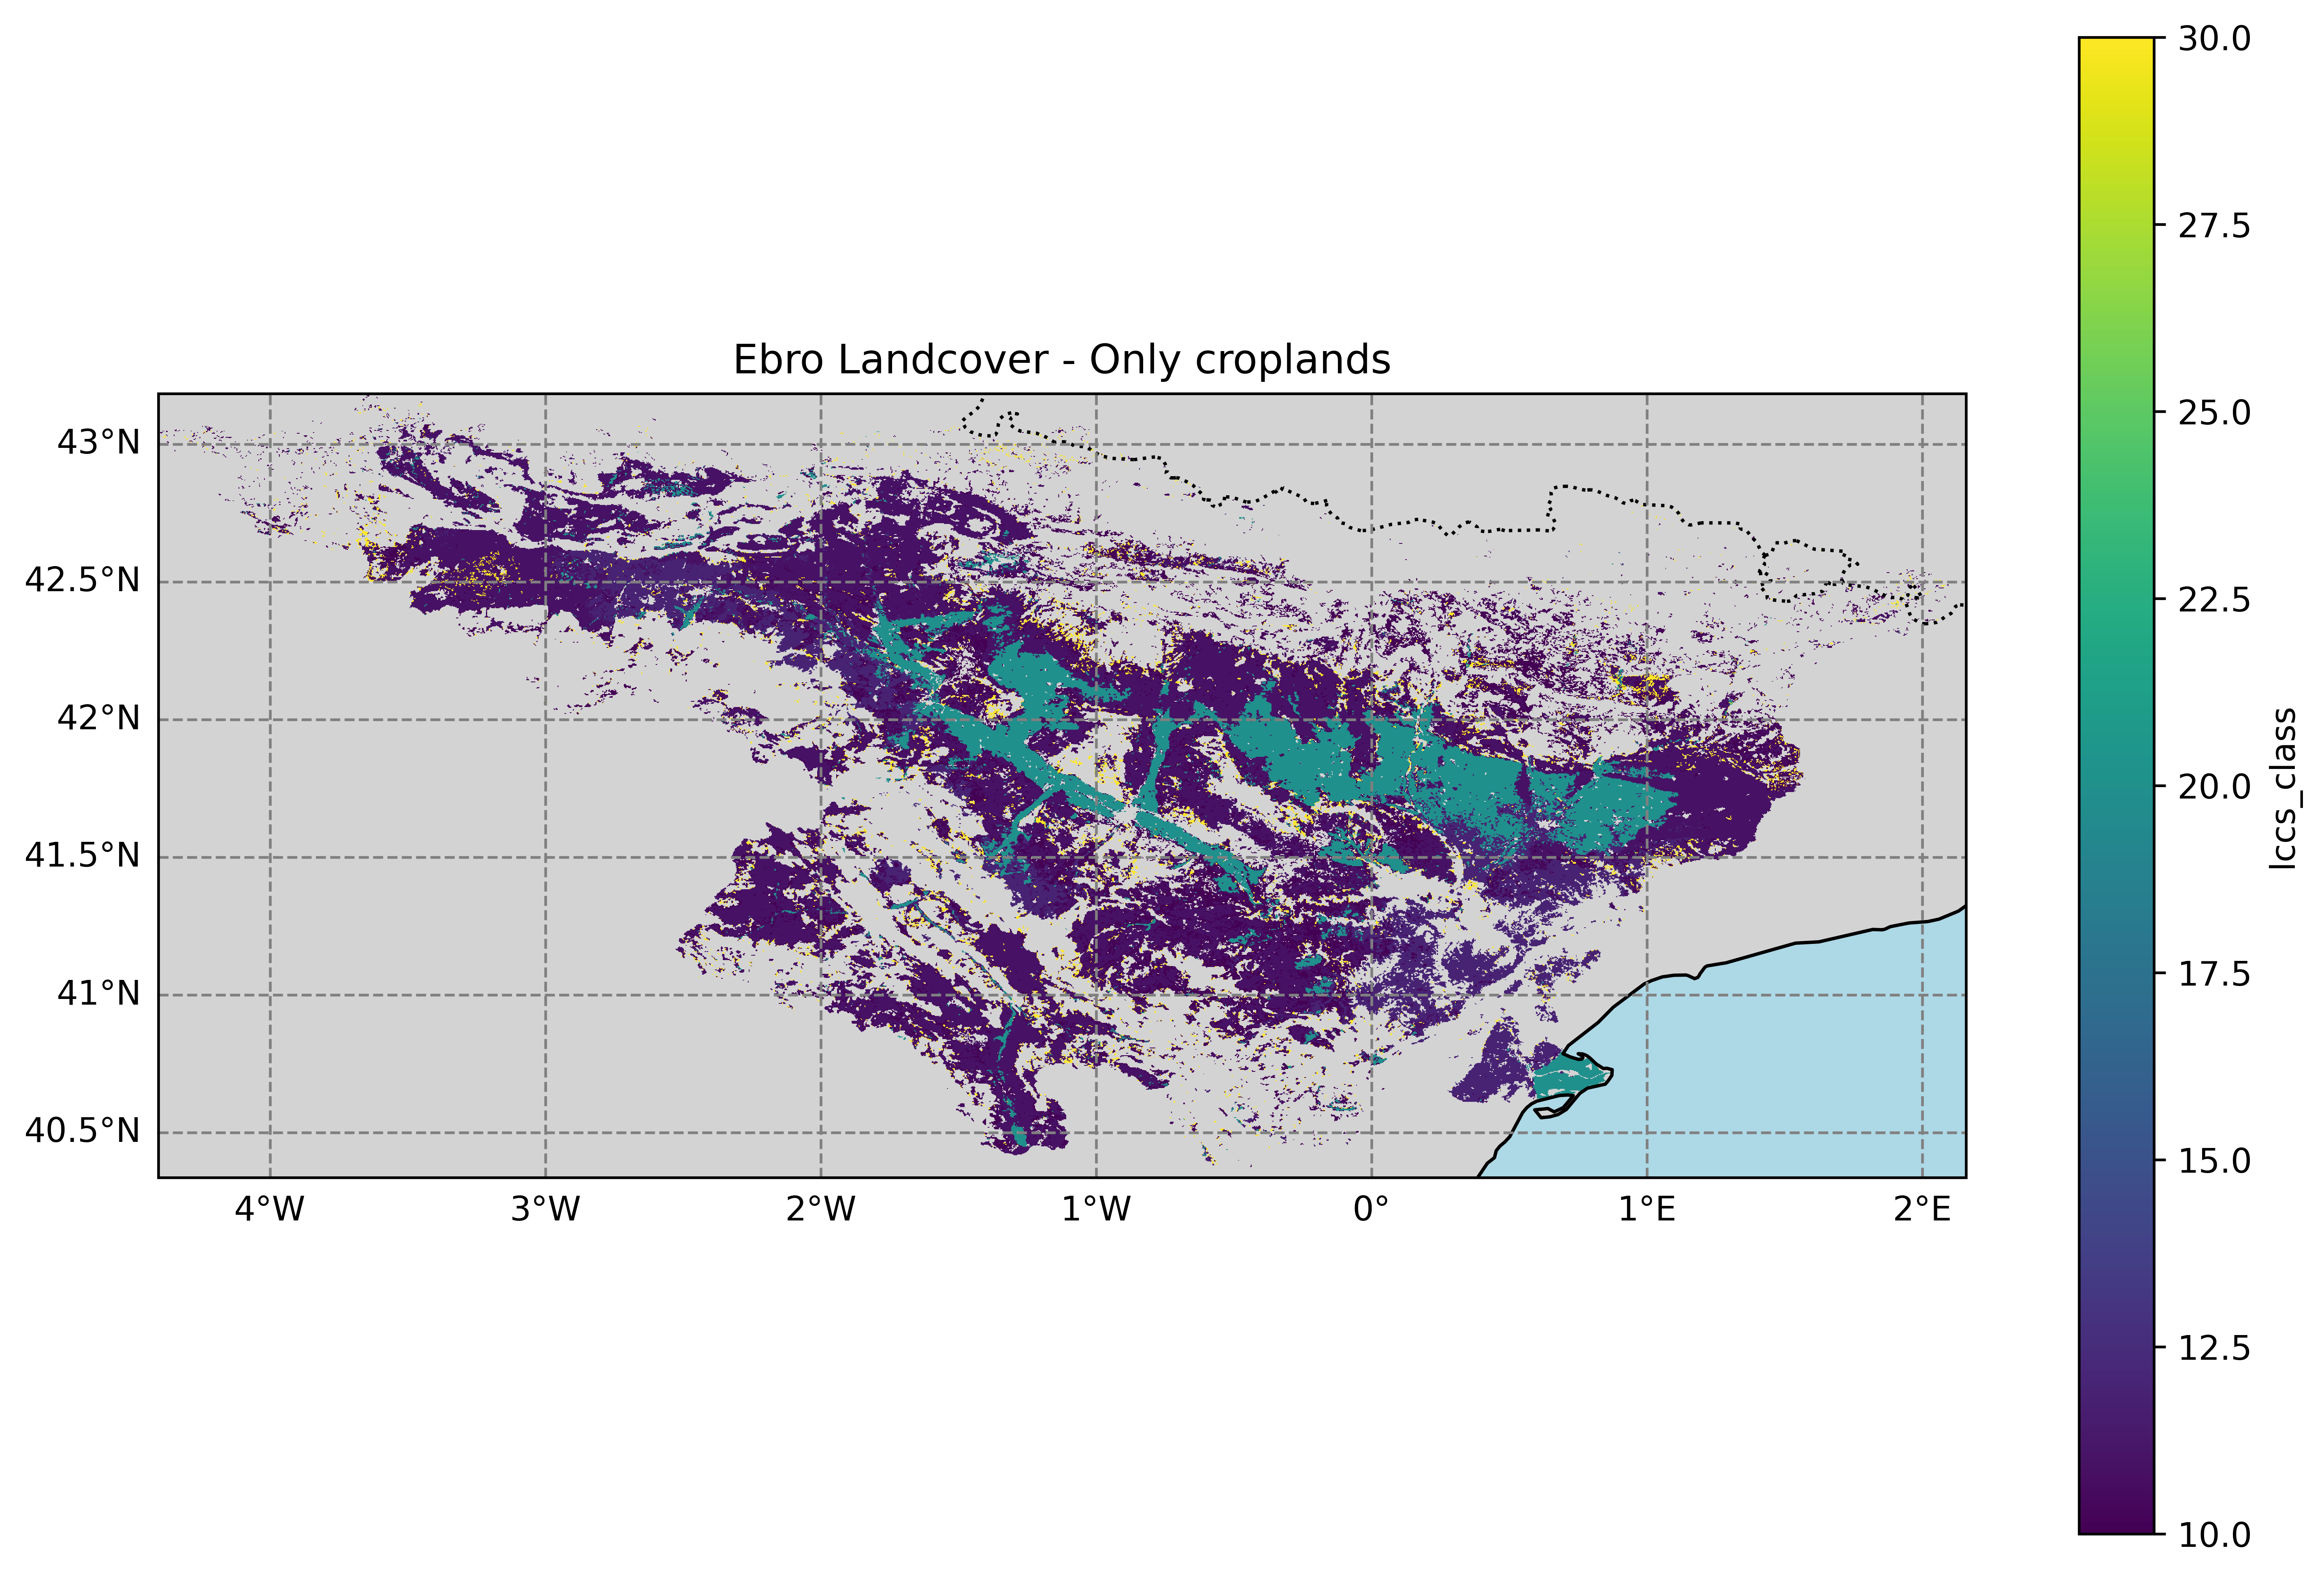

In [39]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = filtered_lc.isel(time=0)
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover - Only croplands")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()


## ERA5 (CDS)

In [40]:
cds_store = new_data_store("cds", normalize_names=True)

In [41]:
data_ids = list(cds_store.get_data_ids())
data_ids

['reanalysis-era5-land-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels:ensemble_mean',
 'reanalysis-era5-single-levels:ensemble_members',
 'reanalysis-era5-single-levels:ensemble_spread',
 'reanalysis-era5-single-levels:reanalysis',
 'reanalysis-era5-land',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_ensemble_members',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_reanalysis',
 'satellite-soil-moisture:saturation:daily',
 'satellite-soil-moisture:saturation:10-day',
 'satellite-soil-moisture:saturation:monthly',
 'satellite-soil-moisture:volumetric:daily',
 'satellite-soil-moisture:volumetric:10-day',
 'satellite-soil-moisture:volumetric:monthly',
 'satellite-sea-ice-thickness:envisat',
 'satellite-sea-ice-thickness:cryosat-2']

In [42]:
data_id = (
    'reanalysis-era5-land'
)

In [43]:
cds_store.get_open_data_params_schema(data_id)

In [48]:
bbox = (-4.40417, 40.3375, 2.15694, 43.18194)
time_range = ("2020-01-01", "2020-01-31")
variables = ("soil_temperature_level_1", "potential_evaporation", "total_precipitation", "snowfall")
spatial_res = 0.1

In [45]:
openers = cds_store.get_data_opener_ids()

openers

('dataset:netcdf:cds',)

In [49]:
cds_cube = cds_store.open_data(
    data_id,
    openers[0],
    variable_names=variables,
    bbox=bbox,
    spatial_res=spatial_res,
    time_range=("2020-01-01", "2020-01-31")
)

xcube-cds version 1.1.0.dev0
2025-08-04 15:15:59,577 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-04 15:15:59,762 INFO Request ID is dab0a261-3c6d-4a69-a4a8-c9f8ddb3b7e2
INFO:ecmwf.datastores.legacy_client:Request ID is dab0a261-3c6d-4a69-a4a8-c9f8ddb3b7e2
2025-08-04 15:15:59,930 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-04 15:16:13,590 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-08-04 15:24:19,450 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


5aec9313e0ef6f87d2165c05402d1531.zip:   0%|          | 0.00/8.72M [00:00<?, ?B/s]

In [55]:
cds_cube = cds_store.open_data(
    data_id,
    openers[0],
    variable_names=variables,
    bbox=bbox,
    spatial_res=spatial_res,
    time_range=("2020-01-01", "2020-12-31"),
)

xcube-cds version 1.1.0.dev0
2025-07-16 16:15:46,811 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


HTTPError: 403 Client Error: Forbidden for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/reanalysis-era5-land/execution
cost limits exceeded
Your request is too large, please reduce your selection.

In [50]:
cds_cube

<xarray.Dataset> Size: 22MB
Dimensions:  (time: 744, lat: 28, lon: 65)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * lat      (lat) float64 224B 43.09 42.99 42.89 42.79 ... 40.59 40.49 40.39
  * lon      (lon) float64 520B -4.355 -4.255 -4.155 ... 1.846 1.946 2.046
    expver   (time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    stl1     (time, lat, lon) float32 5MB dask.array<chunksize=(744, 28, 65), meta=np.ndarray>
    pev      (time, lat, lon) float32 5MB dask.array<chunksize=(744, 28, 65), meta=np.ndarray>
    tp       (time, lat, lon) float32 5MB dask.array<chunksize=(744, 28, 65), meta=np.ndarray>
    sf       (time, lat, lon) float32 5MB dask.array<chunksize=(744, 28, 65), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-04T13:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [27]:
mask = ~filtered_lc.isnull()
mask

<xarray.DataArray 'lccs_class' (lat: 1025, lon: 2363)> Size: 2MB
dask.array<invert, shape=(1025, 2363), dtype=bool, chunksize=(1025, 1586), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 8kB 43.18 43.18 43.18 43.17 ... 40.34 40.34 40.34
  * lon      (lon) float64 19kB -4.404 -4.401 -4.399 ... 2.151 2.154 2.157
    time     datetime64[ns] 8B 2020-01-01

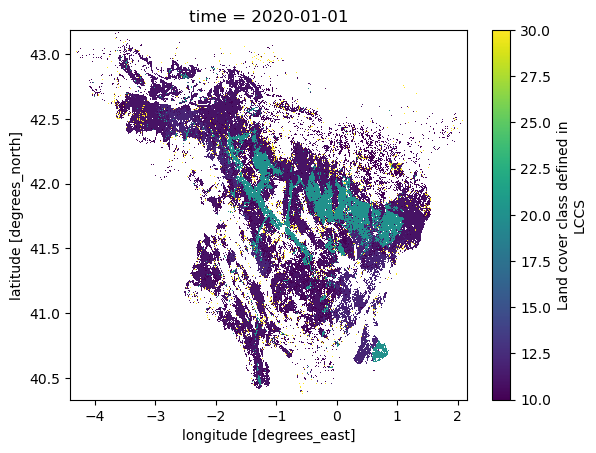

In [28]:
filtered_lc.plot()

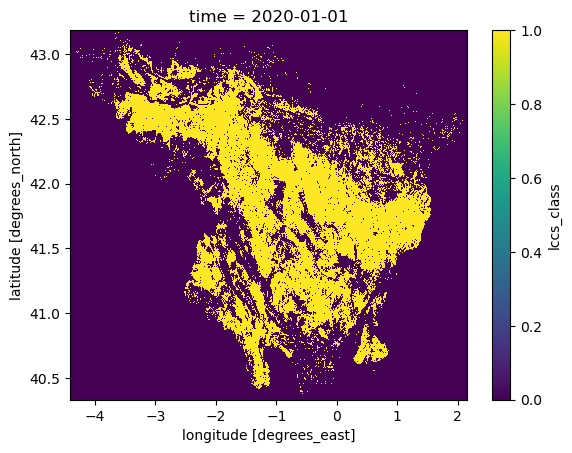

In [29]:
mask.plot()

In [30]:
filtered_lc_resampled = filtered_lc.interp_like(cds_cube, method="nearest")
filtered_lc_resampled

<xarray.DataArray 'lccs_class' (lat: 11, lon: 26)> Size: 1kB
dask.array<transpose, shape=(11, 26), dtype=float32, chunksize=(6, 26), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B 2020-01-01
  * lat      (lat) float64 88B 42.96 42.71 42.46 42.21 ... 40.96 40.71 40.46
  * lon      (lon) float64 208B -4.28 -4.03 -3.78 -3.53 ... 1.471 1.721 1.971
Attributes:
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [0, 10, 11, 12, 20, 30, 40, 50, 60, 61, 62, 70, 71,...
    long_name:            Land cover class defined in LCCS
    standard_name:        land_cover_lccs
    valid_max:            220
    valid_min:            1

In [31]:
mask = ~filtered_lc_resampled.isnull()
mask

<xarray.DataArray 'lccs_class' (lat: 11, lon: 26)> Size: 286B
dask.array<invert, shape=(11, 26), dtype=bool, chunksize=(6, 26), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B 2020-01-01
  * lat      (lat) float64 88B 42.96 42.71 42.46 42.21 ... 40.96 40.71 40.46
  * lon      (lon) float64 208B -4.28 -4.03 -3.78 -3.53 ... 1.471 1.721 1.971

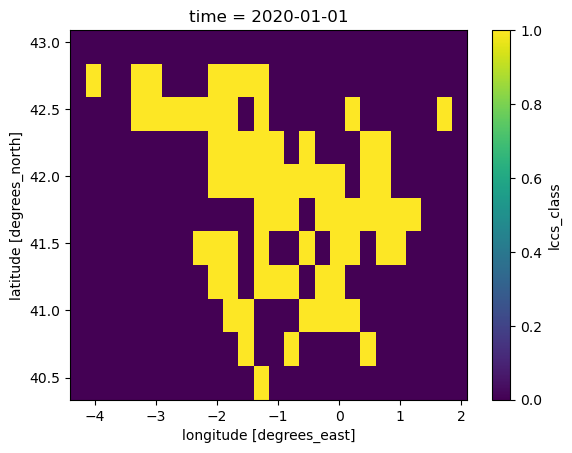

In [32]:
mask.plot()

In [33]:
masked_cds_cube = cds_cube.where(mask)
masked_cds_cube

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 744, lat: 11, lon: 26)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * lat      (lat) float64 88B 42.96 42.71 42.46 42.21 ... 40.96 40.71 40.46
  * lon      (lon) float64 208B -4.28 -4.03 -3.78 -3.53 ... 1.471 1.721 1.971
    expver   (time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    stl1     (time, lat, lon) float32 851kB dask.array<chunksize=(744, 6, 26), meta=np.ndarray>
    pev      (time, lat, lon) float32 851kB dask.array<chunksize=(744, 6, 26), meta=np.ndarray>
    tp       (time, lat, lon) float32 851kB dask.array<chunksize=(744, 6, 26), meta=np.ndarray>
    sf       (time, lat, lon) float32 851kB dask.array<chunksize=(744, 6, 26), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-16T11:16 GRIB to CDM+CF via cfgrib-0.9.1...

In [34]:
cds_gm = GridMapping.from_dataset(cds_cube)
cds_gm

class: **Coords1DGridMapping**
* is_regular: dask.array<all-aggregate, shape=(), dtype=bool, chunksize=(), chunktype=numpy.ndarray>
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.25, 0.25)  _estimated_
* xy_bbox: (-4.405, 40.337, 2.096, 43.088)
* ij_bbox: (0, 0, 26, 11)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (26, 11)
* tile_size: (26, 11)

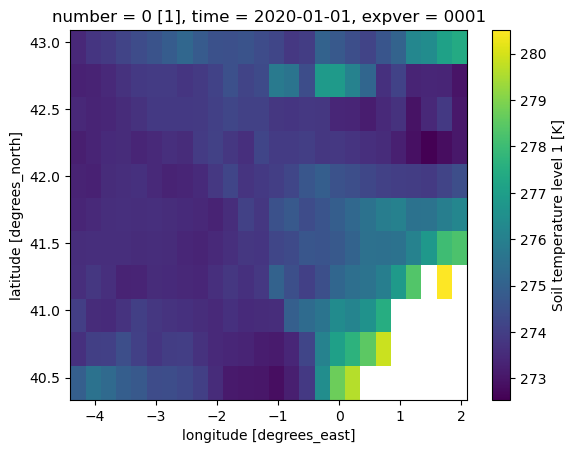

In [35]:
cds_cube.isel(time=0).stl1.plot()

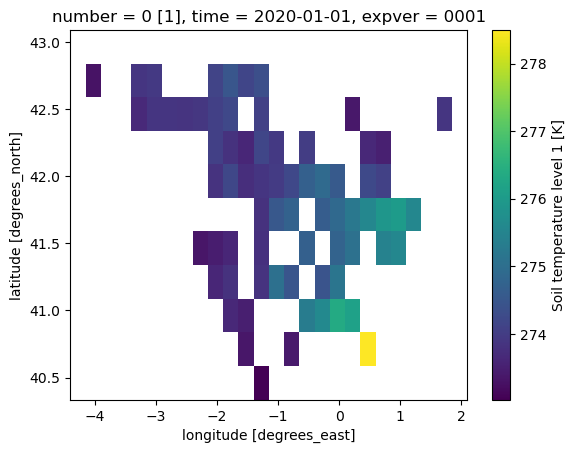

In [36]:
masked_cds_cube.isel(time=0).stl1.plot()

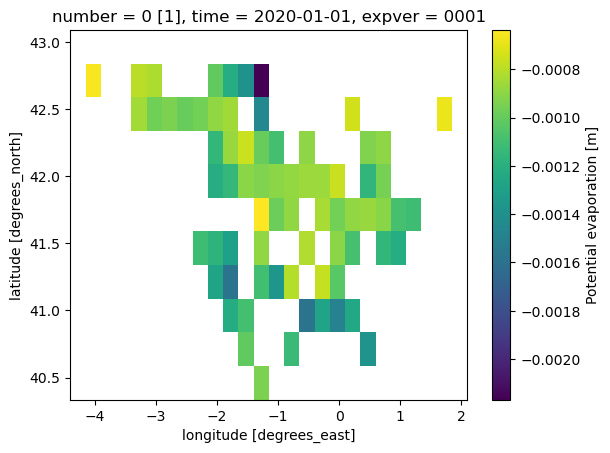

In [37]:
masked_cds_cube.isel(time=0).pev.plot()

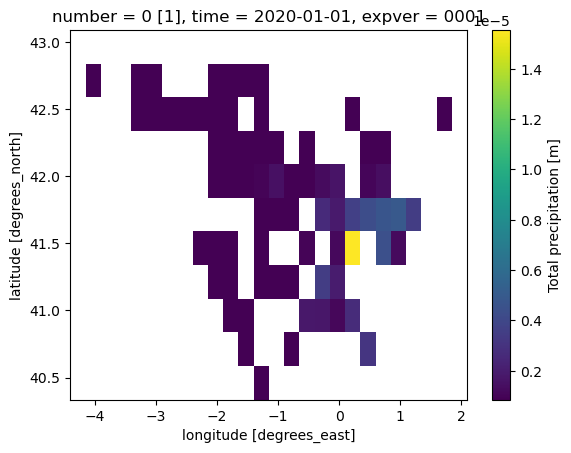

In [38]:
masked_cds_cube.isel(time=0).tp.plot()

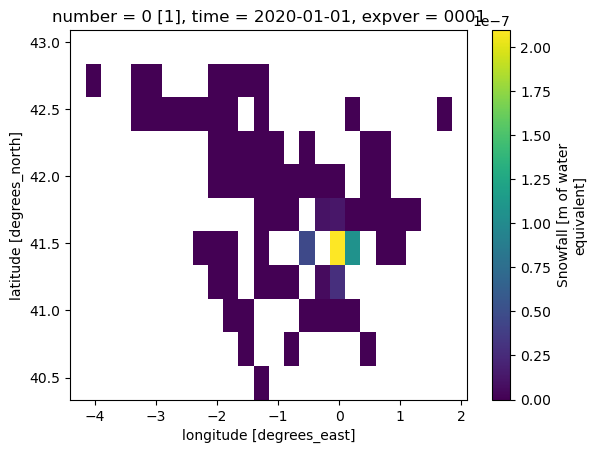

In [39]:
masked_cds_cube.isel(time=0).sf.plot()

## Soil moisture (CLMS)

In [51]:
import json
json_file_path = "credentials.json"
with open(json_file_path, "r") as j:
    credentials = json.loads(j.read())

In [52]:
import logging
logging.getLogger("xcube.clms").setLevel(logging.DEBUG)

In [53]:
%%time
clms_data_store = new_data_store("clms", credentials=credentials)

INFO:xcube.clms:Fetching datasets metadata from https://land.copernicus.eu/api
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=25&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=50&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=75&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=100&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=125&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=150&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search

CPU times: user 944 ms, sys: 110 ms, total: 1.05 s
Wall time: 23.9 s


In [55]:
clms_data_store.has_data("daily-surface-soil-moisture-v1.0")

DEBUG:xcube.clms:Token expired or not present. Refreshing token.
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/@@oauth2-token
DEBUG:xcube.clms:Token refreshed successfully.


True

In [56]:
time_range = ("2020-01-01", "2020-01-31")
soil_moisture = clms_data_store.open_data("daily-surface-soil-moisture-v1.0", time_range=time_range)

DEBUG:xcube.clms:Token expired or not present. Refreshing token.
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/@@oauth2-token
DEBUG:xcube.clms:Token refreshed successfully.
DEBUG:xcube.clms:Token expired or not present. Refreshing token.
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/@@oauth2-token
DEBUG:xcube.clms:Token refreshed successfully.
DEBUG:xcube.clms:Current token valid. Reusing it.
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@get-download-file-urls/?dataset_uid=c073cf8a1d594593bc5d2f9024f0dc60&download_information_id=0524bf44-6624-4e94-b88a-38af27388b31&date_from=2014-01-01&date_to=2025-08-04


In [57]:
soil_moisture

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 31, lat: 4144, lon: 6832)
Coordinates:
  * lat        (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon        (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    crs        (time) |S1 31B b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    ssm        (time, lat, lon) float32 4GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
    ssm_noise  (time, lat, lon) float32 4GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [49]:
import pyproj
crs = pyproj.CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]')
print(crs.to_epsg()) 

4326


In [46]:
sm_gm = GridMapping.from_dataset(soil_moisture)

In [47]:
sm_gm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-11, 35, 50, 72)
* ij_bbox: (0, 0, 6832, 4144)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (6832, 4144)
* tile_size: (2278, 1382)

In [ ]:
bbox = (-4.40417, 40.3375, 2.15694, 43.18194)

In [52]:
soil_moisture.sel(lat=slice(43.18194, 40.3375), lon=slice(-4.40417, 2.15694))

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 31, lat: 318, lon: 735)
Coordinates:
  * lat        (lat) float64 3kB 43.17 43.17 43.16 43.15 ... 40.36 40.35 40.34
  * lon        (lon) float64 6kB -4.397 -4.388 -4.379 ... 2.138 2.147 2.156
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    crs        (time) |S1 31B b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    ssm        (time, lat, lon) float32 29MB dask.array<chunksize=(1, 318, 735), meta=np.ndarray>
    ssm_noise  (time, lat, lon) float32 29MB dask.array<chunksize=(1, 318, 735), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

CPU times: user 428 ms, sys: 49.4 ms, total: 477 ms
Wall time: 306 ms


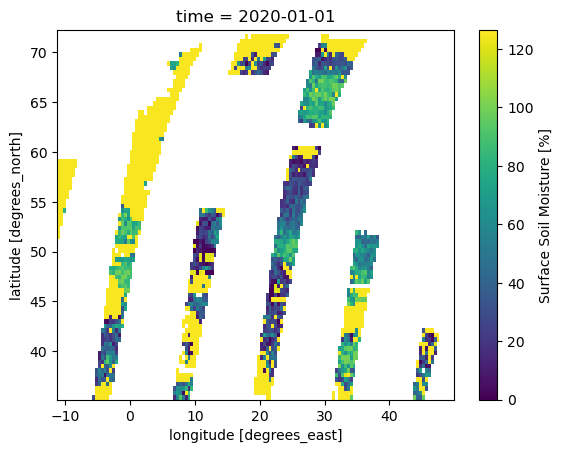

In [61]:
%%time
soil_moisture.isel(time=0, lat=slice(None, None, 50), lon=slice(None, None, 50)).ssm.plot()